# MaleCNS: Whole-Graph Structure and Type-Conditional Prediction

## Context and Methods
MaleCNS v1.0, one adult male CNS. All raw connection records are retained in
30 source/target categories. Superclass is cell identity, not synapse ROI.

### Key Assumptions
Contact-normalized transitions are a supplied structural walk, not measured
neural activity. Type annotations can depend on connectivity. Source-neuron
leave-one-out prediction is conditional on this catalogue, not independent
annotation or animal validation. Positive and negative categories remain visible.

## Data
Input provenance and exact software versions are in the result JSON files.
The full raw scan lives in `whole_structure.py`; prediction and null controls
live in `type_conditioned_closure.py` and `type_label_control.py`.


In [1]:
import hashlib, json
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from IPython.display import Image, display

root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'verify/MaleCNS/whole_structure_result.json').exists())
folder = root / 'verify/MaleCNS'
figures = folder / 'figures/structure-v1'
figures.mkdir(parents=True, exist_ok=True)
whole_path = folder / 'whole_structure_result.json'
type_path = folder / 'type_conditioned_result.json'
whole = json.loads(whole_path.read_text(encoding='utf-8'))
typed = json.loads(type_path.read_text(encoding='utf-8'))
control = json.loads((folder / 'type_label_control_result.json').read_text(encoding='utf-8'))
assert hashlib.sha256(whole_path.read_bytes()).hexdigest() == typed['whole_result_sha256']
assert hashlib.sha256(type_path.read_bytes()).hexdigest() == control['type_result_sha256']
assert whole['rows'] == 151856684 and whole['weight_sum'] == 311833243
plt.rcParams.update({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False, 'figure.dpi': 130})
print(json.dumps({'raw_records': whole['rows'], 'contact_weight': whole['weight_sum'],
                  'selected_sources': typed['selected_annotation_sources'],
                  'analysis_environment': whole['software'],
                  'figure_environment': {'matplotlib': matplotlib.__version__, 'numpy': np.__version__}}, indent=2))


{
  "raw_records": 151856684,
  "contact_weight": 311833243,
  "selected_sources": 166700,
  "analysis_environment": {
    "executable": "C:\\Users\\dongh\\AppData\\Local\\uv\\cache\\archive-v0\\-7582xpefQo_Gdq3\\Scripts\\python.exe",
    "python": "3.14.4",
    "numpy": "2.5.3",
    "pyarrow": "25.0.1"
  },
  "figure_environment": {
    "matplotlib": "3.10.8",
    "numpy": "2.4.6"
  }
}


## Results
### 1. Direction and the unannotated boundary
Every cell in this matrix is a sum of raw contact weights. The logarithmic
colour scale makes small and large flows visible; grey means exactly zero.
The matrix is not a map or a count of neuron-level return paths.


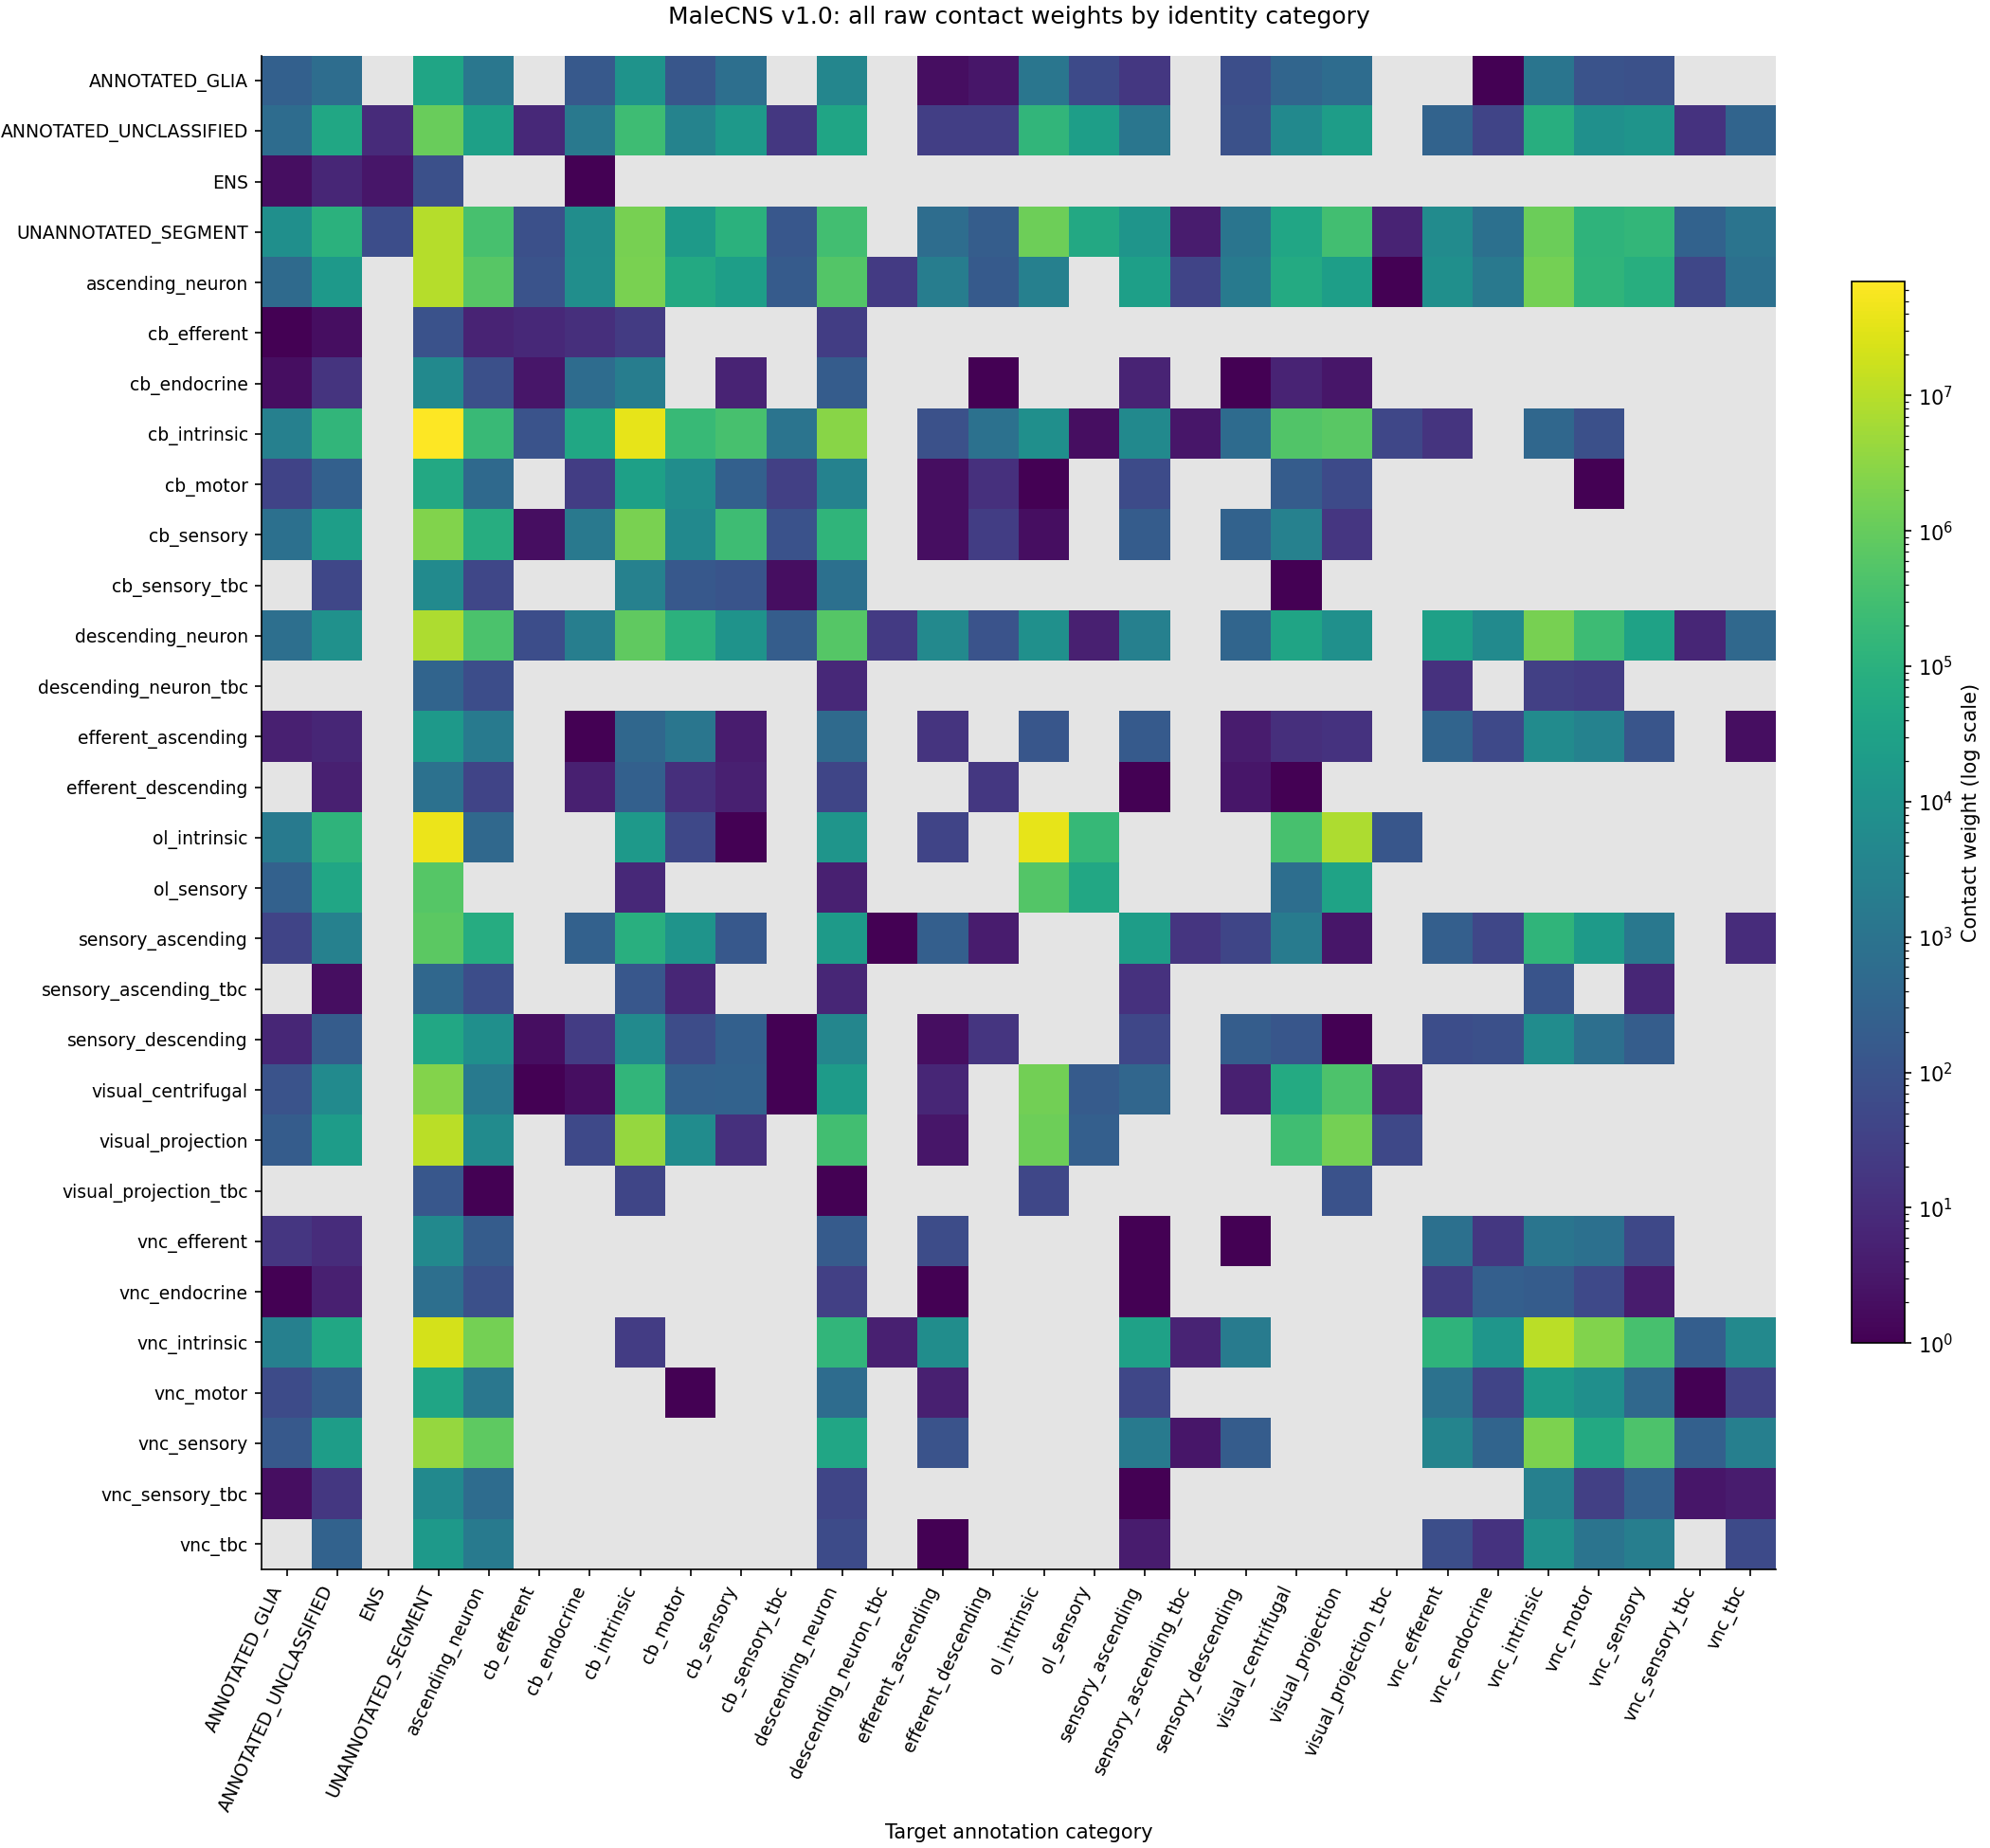

Annotated to unannotated boundary: 171,546,188 / 311,833,243 = 55.0122%


In [2]:
labels = whole['category_order']
lookup = {label: i for i, label in enumerate(labels)}
flow = np.zeros((len(labels), len(labels)), dtype=np.int64)
for row in whole['category_flows']:
    flow[lookup[row['source']], lookup[row['target']]] = row['weight']
assert int(flow.sum()) == whole['weight_sum']
fig, ax = plt.subplots(figsize=(14, 13), layout='constrained')
cmap = plt.get_cmap('viridis').copy()
cmap.set_bad('#e4e4e4')
im = ax.imshow(np.ma.masked_equal(flow, 0), norm=LogNorm(vmin=1, vmax=flow.max()), cmap=cmap)
ax.set_xticks(range(len(labels)), labels, rotation=65, ha='right', fontsize=9)
ax.set_yticks(range(len(labels)), labels, fontsize=9)
ax.set_xlabel('Target annotation category')
ax.set_ylabel('Source annotation category')
ax.set_title('MaleCNS v1.0: all raw contact weights by identity category', pad=16)
fig.colorbar(im, ax=ax, fraction=.035, label='Contact weight (log scale)')
path = figures / 'whole_category_flow.png'
fig.savefig(path, dpi=150)
plt.close(fig)
display(Image(filename=str(path), width=1000))
unknown = lookup['UNANNOTATED_SEGMENT']
annotated_to_unknown = int(flow[:, unknown].sum() - flow[unknown, unknown])
print(f'Annotated to unannotated boundary: {annotated_to_unknown:,} / {flow.sum():,} = {annotated_to_unknown / flow.sum():.4%}')


### 2. Predicting a held-out source from other cells
Both models remove the complete held-out source row. The type model falls back
to superclass-only prediction when no positive-outflow same-type peer exists.
All 30 target categories remain in each prediction. Total Dirichlet smoothing
is alpha=1 in the figure; alpha=10 and 100 are retained below. Lower loss is better.


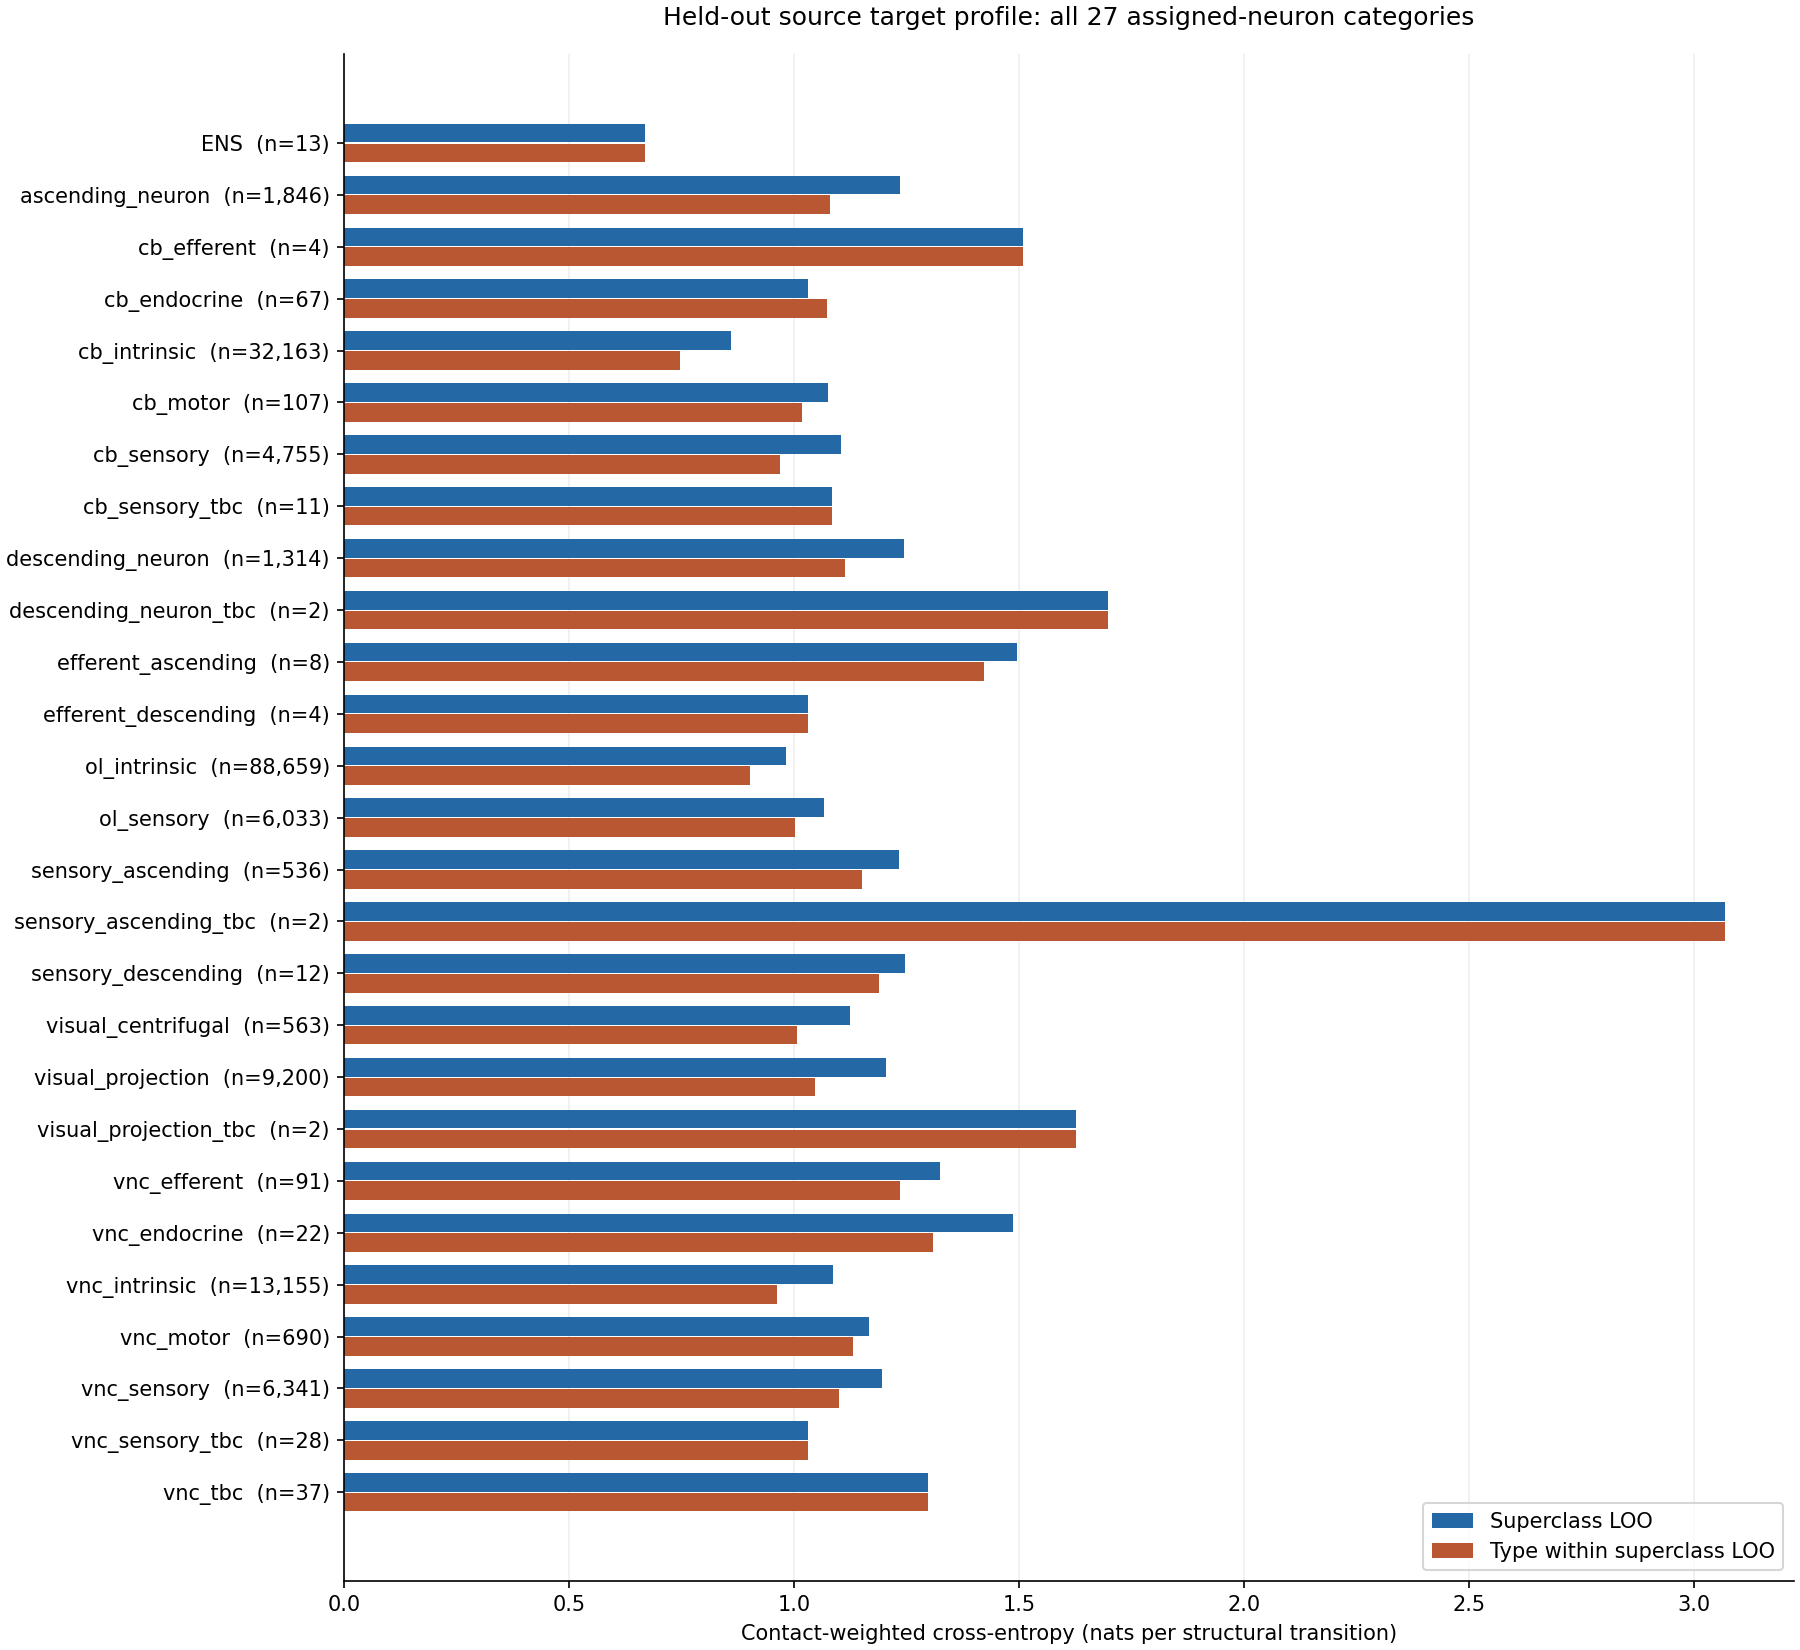

alpha=1: loss 0.995924 -> 0.886486; reduction 10.989%
alpha=10: loss 0.995921 -> 0.886633; reduction 10.974%
alpha=100: loss 0.995925 -> 0.890706; reduction 10.565%


In [3]:
primary = typed['predictions'][0]
rows = primary['categories']
y = np.arange(len(rows))
fig, ax = plt.subplots(figsize=(12, 11), layout='constrained')
ax.barh(y-.19, [r['parent_loss'] for r in rows], height=.36, label='Superclass LOO', color='#2568a6')
ax.barh(y+.19, [r['type_loss'] for r in rows], height=.36, label='Type within superclass LOO', color='#b95732')
ax.set_yticks(y, [f"{r['category']}  (n={r['sources']:,})" for r in rows], fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Contact-weighted cross-entropy (nats per structural transition)')
ax.set_title('Held-out source target profile: all 27 assigned-neuron categories', pad=14)
ax.grid(axis='x', alpha=.2)
ax.set_axisbelow(True)
ax.legend(loc='lower right')
path = figures / 'type_source_loo.png'
fig.savefig(path, dpi=150)
plt.close(fig)
display(Image(filename=str(path), width=1000))
for prediction in typed['predictions']:
    value = prediction['all']
    print(f"alpha={prediction['total_dirichlet_pseudocount']:g}: loss {value['parent_loss']:.6f} -> {value['type_loss']:.6f}; reduction {value['relative_loss_reduction']:.3%}")


### 3. Type-label controls
Each point is one complete label permutation, not an independent animal. Source
degrees, all observed counts and label margins stay fixed. The second control
also preserves label counts within each superclass's out-weight decile.
Missing-type and zero-out sources stay fixed. This figure does not report a p-value.


within_superclass: 24 replicates, range [-7.1130, -6.6490] percent
within_superclass_degree_decile: 24 replicates, range [-7.0202, -6.5975] percent


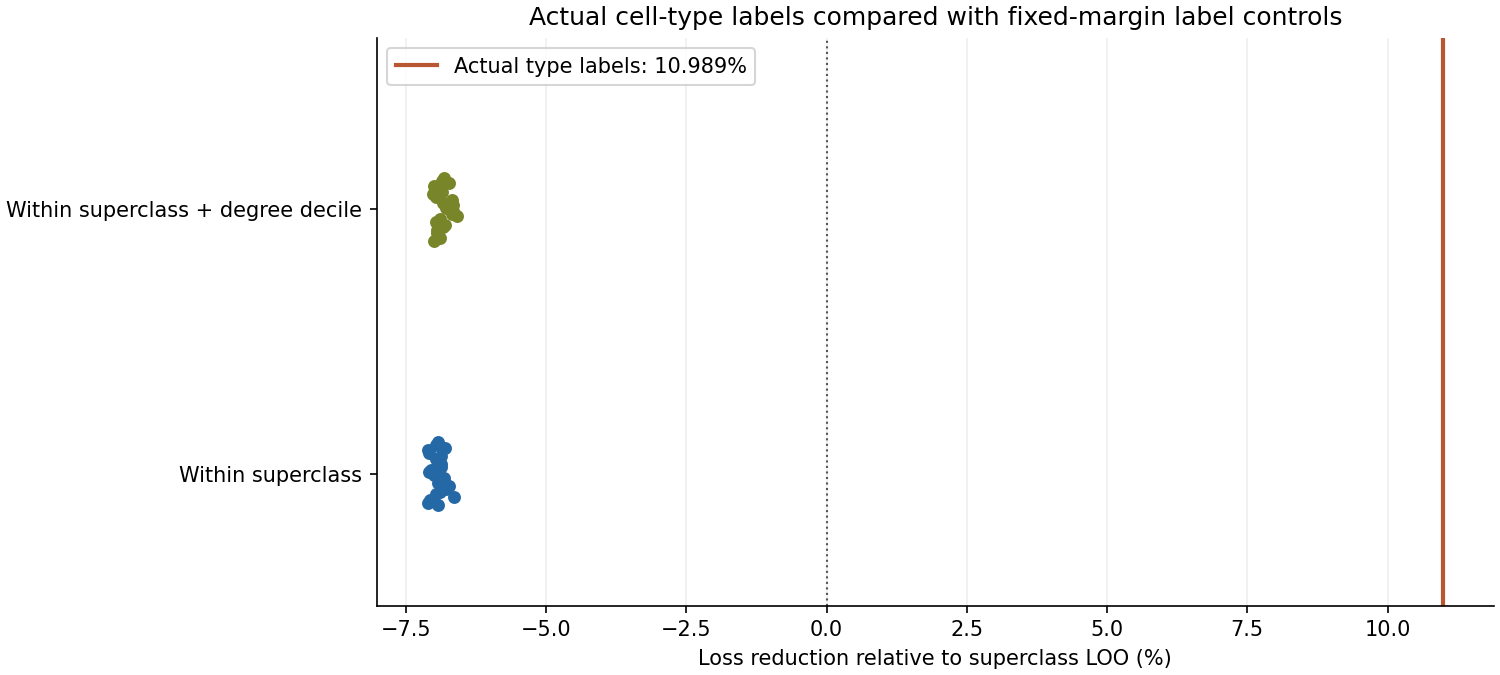

In [4]:
families = ['within_superclass', 'within_superclass_degree_decile']
names = ['Within superclass', 'Within superclass + degree decile']
observed = 100 * control['observed']['relative_loss_reduction']
fig, ax = plt.subplots(figsize=(10, 4.5), layout='constrained')
for index, family in enumerate(families):
    values = [100*r['relative_loss_reduction'] for r in control['controls'] if r['family'] == family]
    ax.scatter(values, index + np.linspace(-.12, .12, len(values)), color=['#2568a6', '#788529'][index], s=27)
    print(f'{family}: {len(values)} replicates, range [{min(values):.4f}, {max(values):.4f}] percent')
ax.axvline(observed, color='#b95732', label=f'Actual type labels: {observed:.3f}%', linewidth=2)
ax.axvline(0, color='#555555', linestyle=':', linewidth=1)
ax.set_yticks([0, 1], names)
ax.set_ylim(-.5, 1.65)
ax.set_xlabel('Loss reduction relative to superclass LOO (%)')
ax.set_title('Actual cell-type labels compared with fixed-margin label controls')
ax.grid(axis='x', alpha=.2)
ax.legend(loc='upper left')
path = figures / 'type_label_controls.png'
fig.savefig(path, dpi=150)
plt.close(fig)
display(Image(filename=str(path), width=1000))


## Takeaways and Limits
The actual catalogue contains directed, heterogeneous target profiles. Finer
type labels improve source-held-out profile prediction over broad superclass,
but this does not establish a learning mechanism or biological memory.

The unannotated boundary is substantial. Small categories and strong smoothing
can produce negative results. Counts are from one reconstructed CNS; synaptic
partners are not independent animals, and catalogue labels can incorporate the
same connectivity. Next tests must separate type, degree, spatial/ROI structure,
and actual neuron-level return paths before interpreting hidden-state dynamics.

Official source: https://male-cns.janelia.org/download/
Detailed Korean narrative and limitations: `paper/6_뇌/13_MaleCNS_전체망_기하와기억/`.
